# Домашнее задание. Решение конкурса на kaggle.com

Это домашнее задание посвящено полноценному решению задачи машинного обучения.

Есть две части этого домашнего задания:

### Отправить ваши предсказания в Stepik.
За прохождение определенных порогов будут начисляться баллы. Эта часть оценивается из 5 баллов.

1) $1.00 \geqslant score \geqslant 0.84$ --- 5 баллов

2) $0.84 > score \geqslant 0.77$ --- 4 балла

3) $0.77 > score \geqslant 0.70$ --- 3 балла

4) $0.70 > score \geqslant 0.65$ --- 2 балла

5) $0.65 > score \geqslant 0.6$ --- 1 балл

6) $0.60 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на две части.
* `train.csv`. На этом наборе данных вам необходимо создать и обучить модель. Подробное описание файла есть в ноутбуке.
* `test.csv`. В каждой строчке файла `test.csv` указаны признаки тестовых объектов. Предсказания для этого набора необходимо записать в файл submission.csv и сдать в соответствующий шаг на Stepik. Количество попыток ограничено 100 штук.

Отправлять в Stepik вы будете файл с ответами `my_submission.csv`. В этом файле вам необходимо для каждого объекта из датасета предсказать вероятность класса 1. Мы подготовили для вас файл с примером посылки `submission.csv`. Ваш файл должен быть оформлен таким же образом. В ноутбуке есть пример оформления файла посылки. Для отправки файла с предсказаниями на Stepik есть отдельный шаг.

### Сделать полноценный отчет о вашей работе.
Опишите, как вы обработали данные, какие модели попробовали и какие результаты получились (максимум 10 баллов). За каждую выполненную часть будет начислено определенное количество баллов. В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается из 10 баллов.

**Вторая часть будет проверяться в формате peer-review. Т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.**

### Контест на Kaggle
Для вашего удобства мы подготовили [контест на Kaggle](https://www.kaggle.com/c/advanced-dls-spring-2021/). Тестирующая система на Kaggle выдает те же баллы, что и Stepik. Мы рекомендуем в качестве основной тестирующей системы использовать именно Kaggle, а затем сдать лучшую посылку на Stepik. Так вы привыкните работать с Kaggle.

Проблема для российских пользователей Kaggle заключается в том, что подтверждение аккаунта по номеру телефона работает с перебоями или не работает вообще. Без подтвержденного номера телефона вы не сможете совершать посылки в kaggle. Если у вас возникла такая проблема, мы советуем следующие шаги:
* Попробовать зарегистрировать аккаунт с аутентификацией через gmail. В таком случае, аккаунт должен работать без подтверждения номера телефона.
* Если у вас есть не российский номер, используйте его для верификации аккаунта.
* Если на номер телефона не приходит смс для верификации аккаунта, обратитесь в службу поддержки kaggle. Они с переменным успехом умеют подтверждать аккаунты вручную.
* Если все же подтвердить аккаунт и получить доступ к сдаче заданий не удалось, используйте только сдачу в Stepik.

### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


Данные: [train.csv](https://drive.google.com/file/d/1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K/view?usp=share_link),
[test.csv](https://drive.google.com/file/d/1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r/view?usp=share_link), [submission.csv](https://drive.google.com/file/d/199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y/view?usp=share_link).

Если ссылки на данные не работают, их можно скачать [на Kaggle](https://www.kaggle.com/competitions/advanced-dls-spring-2021/data).

# Как проверять?

Ставьте полный балл, если выполнены все рекомендации или сделано что-то более интересное и сложное. За каждый отсустствующий пункт из рекомендации снижайте 1 балл.

**Если решение верное, но не удовлетворяет вашим эстетическим предпочтениям, за это баллы снижать не нужно.**

# Метрика

Перед решением любой задачи важно понимать, как будет оцениваться ваше решение. В данном случае мы используем стандартную для задачи классификации метрику ROC-AUC. Ее можно вычислить, используя только предсказанные вероятности и истинные классы без конкретного порога классификации + она раотает даже если классы в данных сильно несбалансированны (примеров одного класса в десятки раз больше примеров длугого). Именно поэтому она очень удобна для соревнований.

Посчитать ее легко:


In [10]:
from sklearn.metrics import roc_auc_score

y_true = [
    0,
    1,
    1,
    0,
    1
]

y_predictions = [
    0.1,
    0.9,
    0.4,
    0.6,
    0.61
]

roc_auc_score(y_true, y_predictions)

0.8333333333333333

# Первая часть. Исследование

In [11]:
import numpy as np
import polars as pl
import polars.selectors as cs
import os

import matplotlib.pyplot as plt
import pyarrow as pa
import pandas as pd
import plotly.express as px

In [12]:
# Set global configuration for number formatting
pl.Config.set_fmt_str_lengths(100)  # For longer string display
pl.Config.set_tbl_formatting("UTF8_FULL_CONDENSED")
pl.Config.set_tbl_cell_numeric_alignment("RIGHT")
pl.Config.set_tbl_rows(20)
pl.Config.set_thousands_separator(",")  # Set thousands separator
pl.Config.set_float_precision(2)  # Set decimal places

polars.config.Config

## Загрузка данных (2 балла)

1) Посмотрите на случайные строчки.

2) Посмотрите, есть ли в датасете незаполненные значения (nan'ы) с помощью data.isna() или data.info() и, если нужно, замените их на что-то. Будет хорошо, если вы построите табличку с количеством nan в каждой колонке.

In [13]:
# !gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
# !gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
# !gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

In [14]:
data = pl.read_csv('./train.csv')

In [15]:
data.sample(5)

ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
i64,f64,f64,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64
1,20.95,20.95,"""Male""",0,"""No""","""No""","""Yes""","""No""","""No""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""Month-to-month""","""No""","""Bank transfer (automatic)""",0
1,89.25,89.25,"""Male""",0,"""No""","""No""","""Yes""","""No""","""Fiber optic""","""No""","""No""","""No""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",0
61,69.90,"4,226.70","""Male""",0,"""Yes""","""No""","""Yes""","""Yes""","""DSL""","""Yes""","""No""","""Yes""","""No""","""No""","""Yes""","""Two year""","""Yes""","""Mailed check""",0
45,109.75,"4,900.65","""Male""",0,"""Yes""","""Yes""","""Yes""","""Yes""","""Fiber optic""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Two year""","""Yes""","""Bank transfer (automatic)""",0
5,20.50,104.30,"""Female""",0,"""No""","""No""","""Yes""","""No""","""No""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""Month-to-month""","""Yes""","""Mailed check""",0


In [16]:
# Для вашего удобства списки с именами разных колонок

# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [17]:
data.describe()

statistic,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
str,f64,f64,f64,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64
"""count""","5,282.00","5,282.00","5,273.00","""5282""","5,282.00","""5282""","""5282""","""5282""","""5282""","""5282""","""5282""","""5282""","""5282""","""5282""","""5282""","""5282""","""5282""","""5282""","""5282""","5,282.00"
"""null_count""",0.00,0.00,9.00,"""0""",0.00,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.00
"""mean""",32.40,64.92,"2,291.39",null,0.16,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.26
"""std""",24.55,30.18,"2,269.01",null,0.37,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.44
"""min""",0.00,18.25,18.80,"""Female""",0.00,"""No""","""No""","""No""","""No""","""DSL""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""No""","""Bank transfer (automatic)""",0.00
"""25%""",9.00,35.45,401.10,null,0.00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.00
"""50%""",29.00,70.40,"1,410.25",null,0.00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.00
"""75%""",55.00,90.05,"3,807.35",null,0.00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.00
"""max""",72.00,118.75,"8,684.80","""Male""",1.00,"""Yes""","""Yes""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Two year""","""Yes""","""Mailed check""",1.00


проверим nun

In [18]:
# Check for null values in all columns
data.null_count()

ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


заменим nan средним значением 

In [19]:
data = data.with_columns(pl.col('TotalSpent').fill_null(pl.col('TotalSpent').mean()))

## Анализ данных (3 балла)

1) Для численных призанков постройте гистограмму (*plt.hist(...)*) или boxplot (*plt.boxplot(...)*). Для категориальных посчитайте количество каждого значения для каждого признака. Для каждой колонки надо сделать *data.value_counts()* и построить bar диаграммы *plt.bar(...)* или круговые диаграммы *plt.pie(...)* (хорошо, елси вы сможете это сделать на одном гарфике с помощью *plt.subplots(...)*).

2) Посмотрите на распределение целевой переменной и скажите, являются ли классы несбалансированными.

3) (Если будет желание) Поиграйте с разными библиотеками для визуализации - *sns*, *pandas_visual_analysis*, etc.

Второй пункт очень важен, потому что существуют задачи классификации с несбалансированными классами. Например, это может значить, что в датасете намного больше примеров 0 класса. В таких случаях нужно 1) не использовать accuracy как метрику 2) использовать методы борьбы с imbalanced dataset (обычно если датасет сильно несбалансирован, т.е. класса 1 в 20 раз меньше класса 0).

#### Распределение числовых признаков

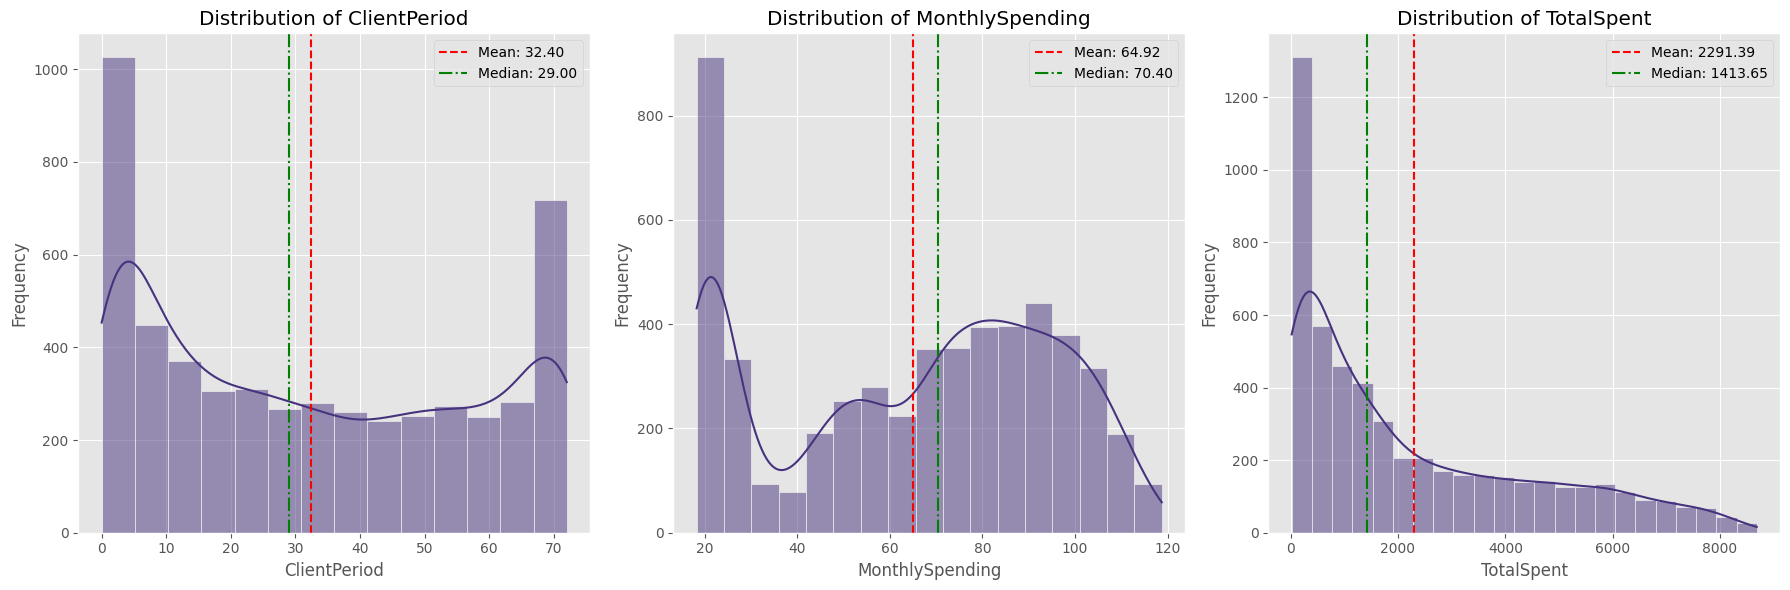

In [20]:
import matplotlib.pyplot as plt

import seaborn as sns

# Set the style for better visualization
plt.style.use('ggplot')
sns.set_palette('viridis')

# Create a figure with 3 subplots for each numeric feature
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot histograms for each numeric feature
for i, col in enumerate(num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    # Add mean and median lines
    mean_val = data[col].mean()
    median_val = data[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-.', label=f'Median: {median_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [21]:
for col in cat_cols:
    print(f"\n=== Value counts for {col} ===")
    counts = data.select(pl.col(col).value_counts()).unnest(col)
    display(counts)


=== Value counts for Sex ===


Sex,count
str,u32
"""Male""","2,655"
"""Female""","2,627"



=== Value counts for IsSeniorCitizen ===


IsSeniorCitizen,count
i64,u32
0,"4,440"
1,842



=== Value counts for HasPartner ===


...

HasContractPhone,count
str,u32
"""Month-to-month""","2,920"
"""One year""","1,082"
"""Two year""","1,280"



=== Value counts for IsBillingPaperless ===


IsBillingPaperless,count
str,u32
"""Yes""","3,148"
"""No""","2,134"



=== Value counts for PaymentMethod ===


PaymentMethod,count
str,u32
"""Bank transfer (automatic)""","1,159"
"""Electronic check""","1,786"
"""Mailed check""","1,194"
"""Credit card (automatic)""","1,143"


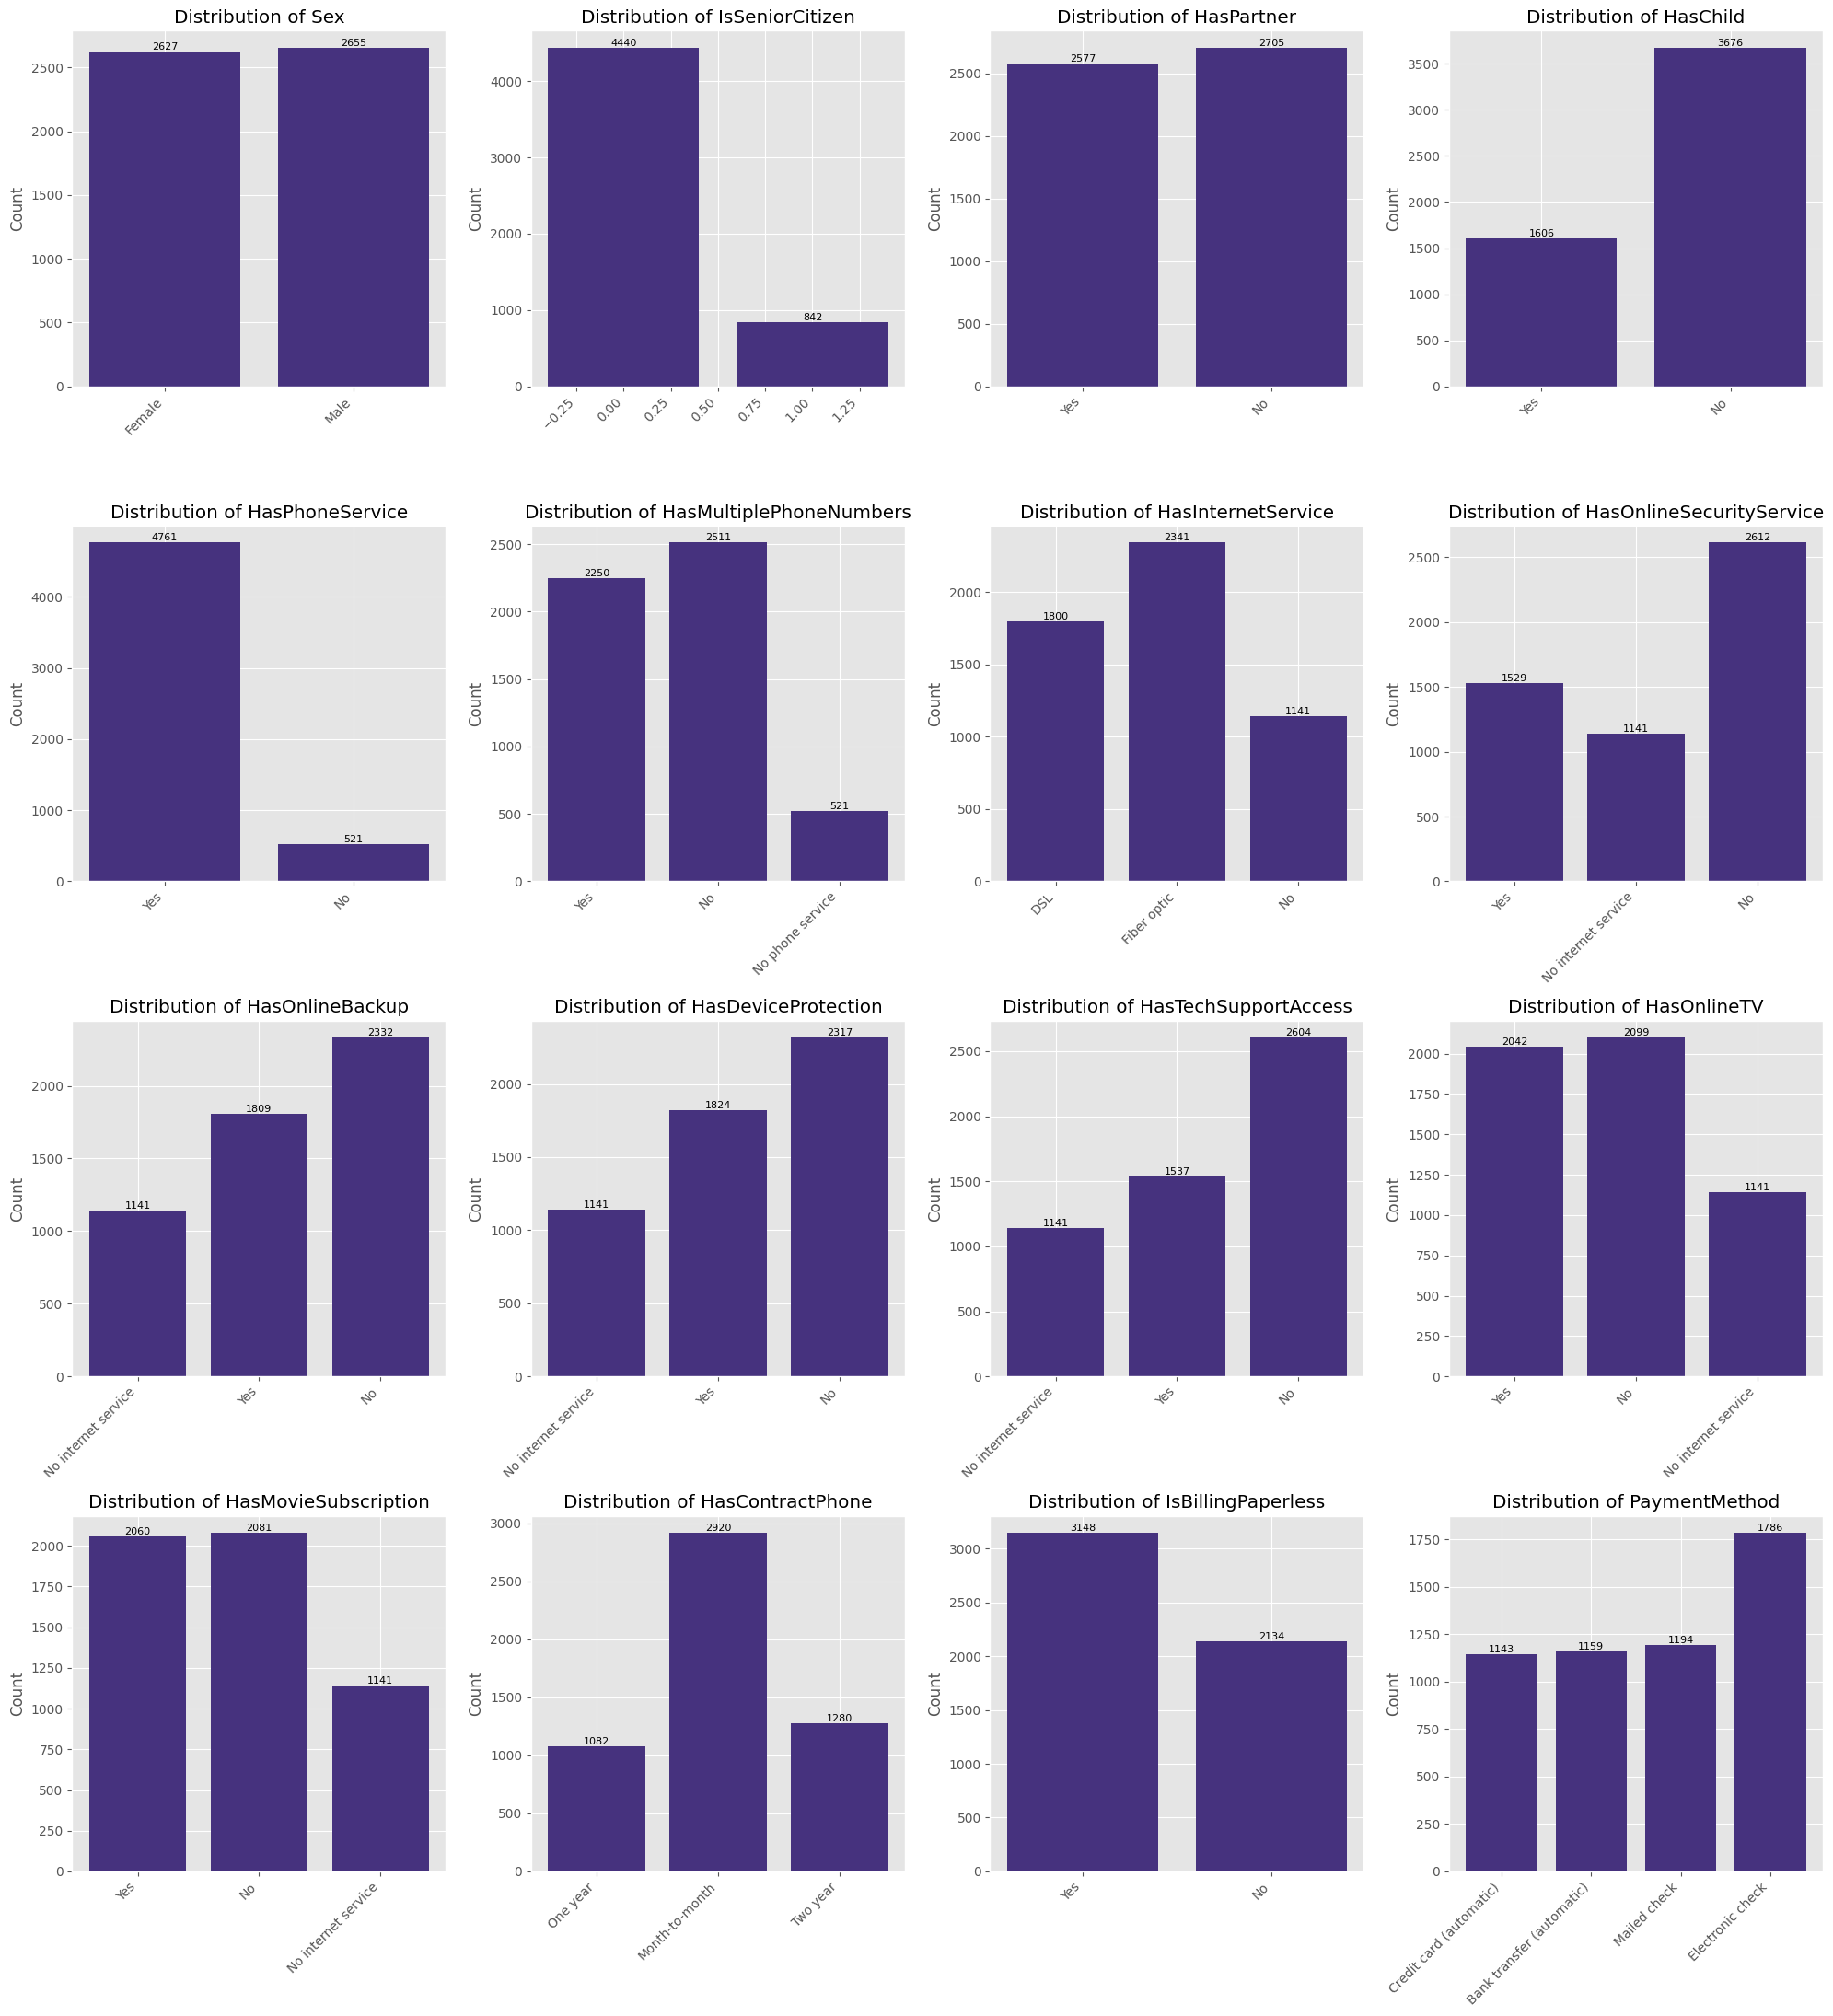

/tmp/ipykernel_63951/3304632103.py:48: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  grouped = data.group_by(col).agg(pl.count().alias("count"))


<Figure size 2000x2200 with 0 Axes>

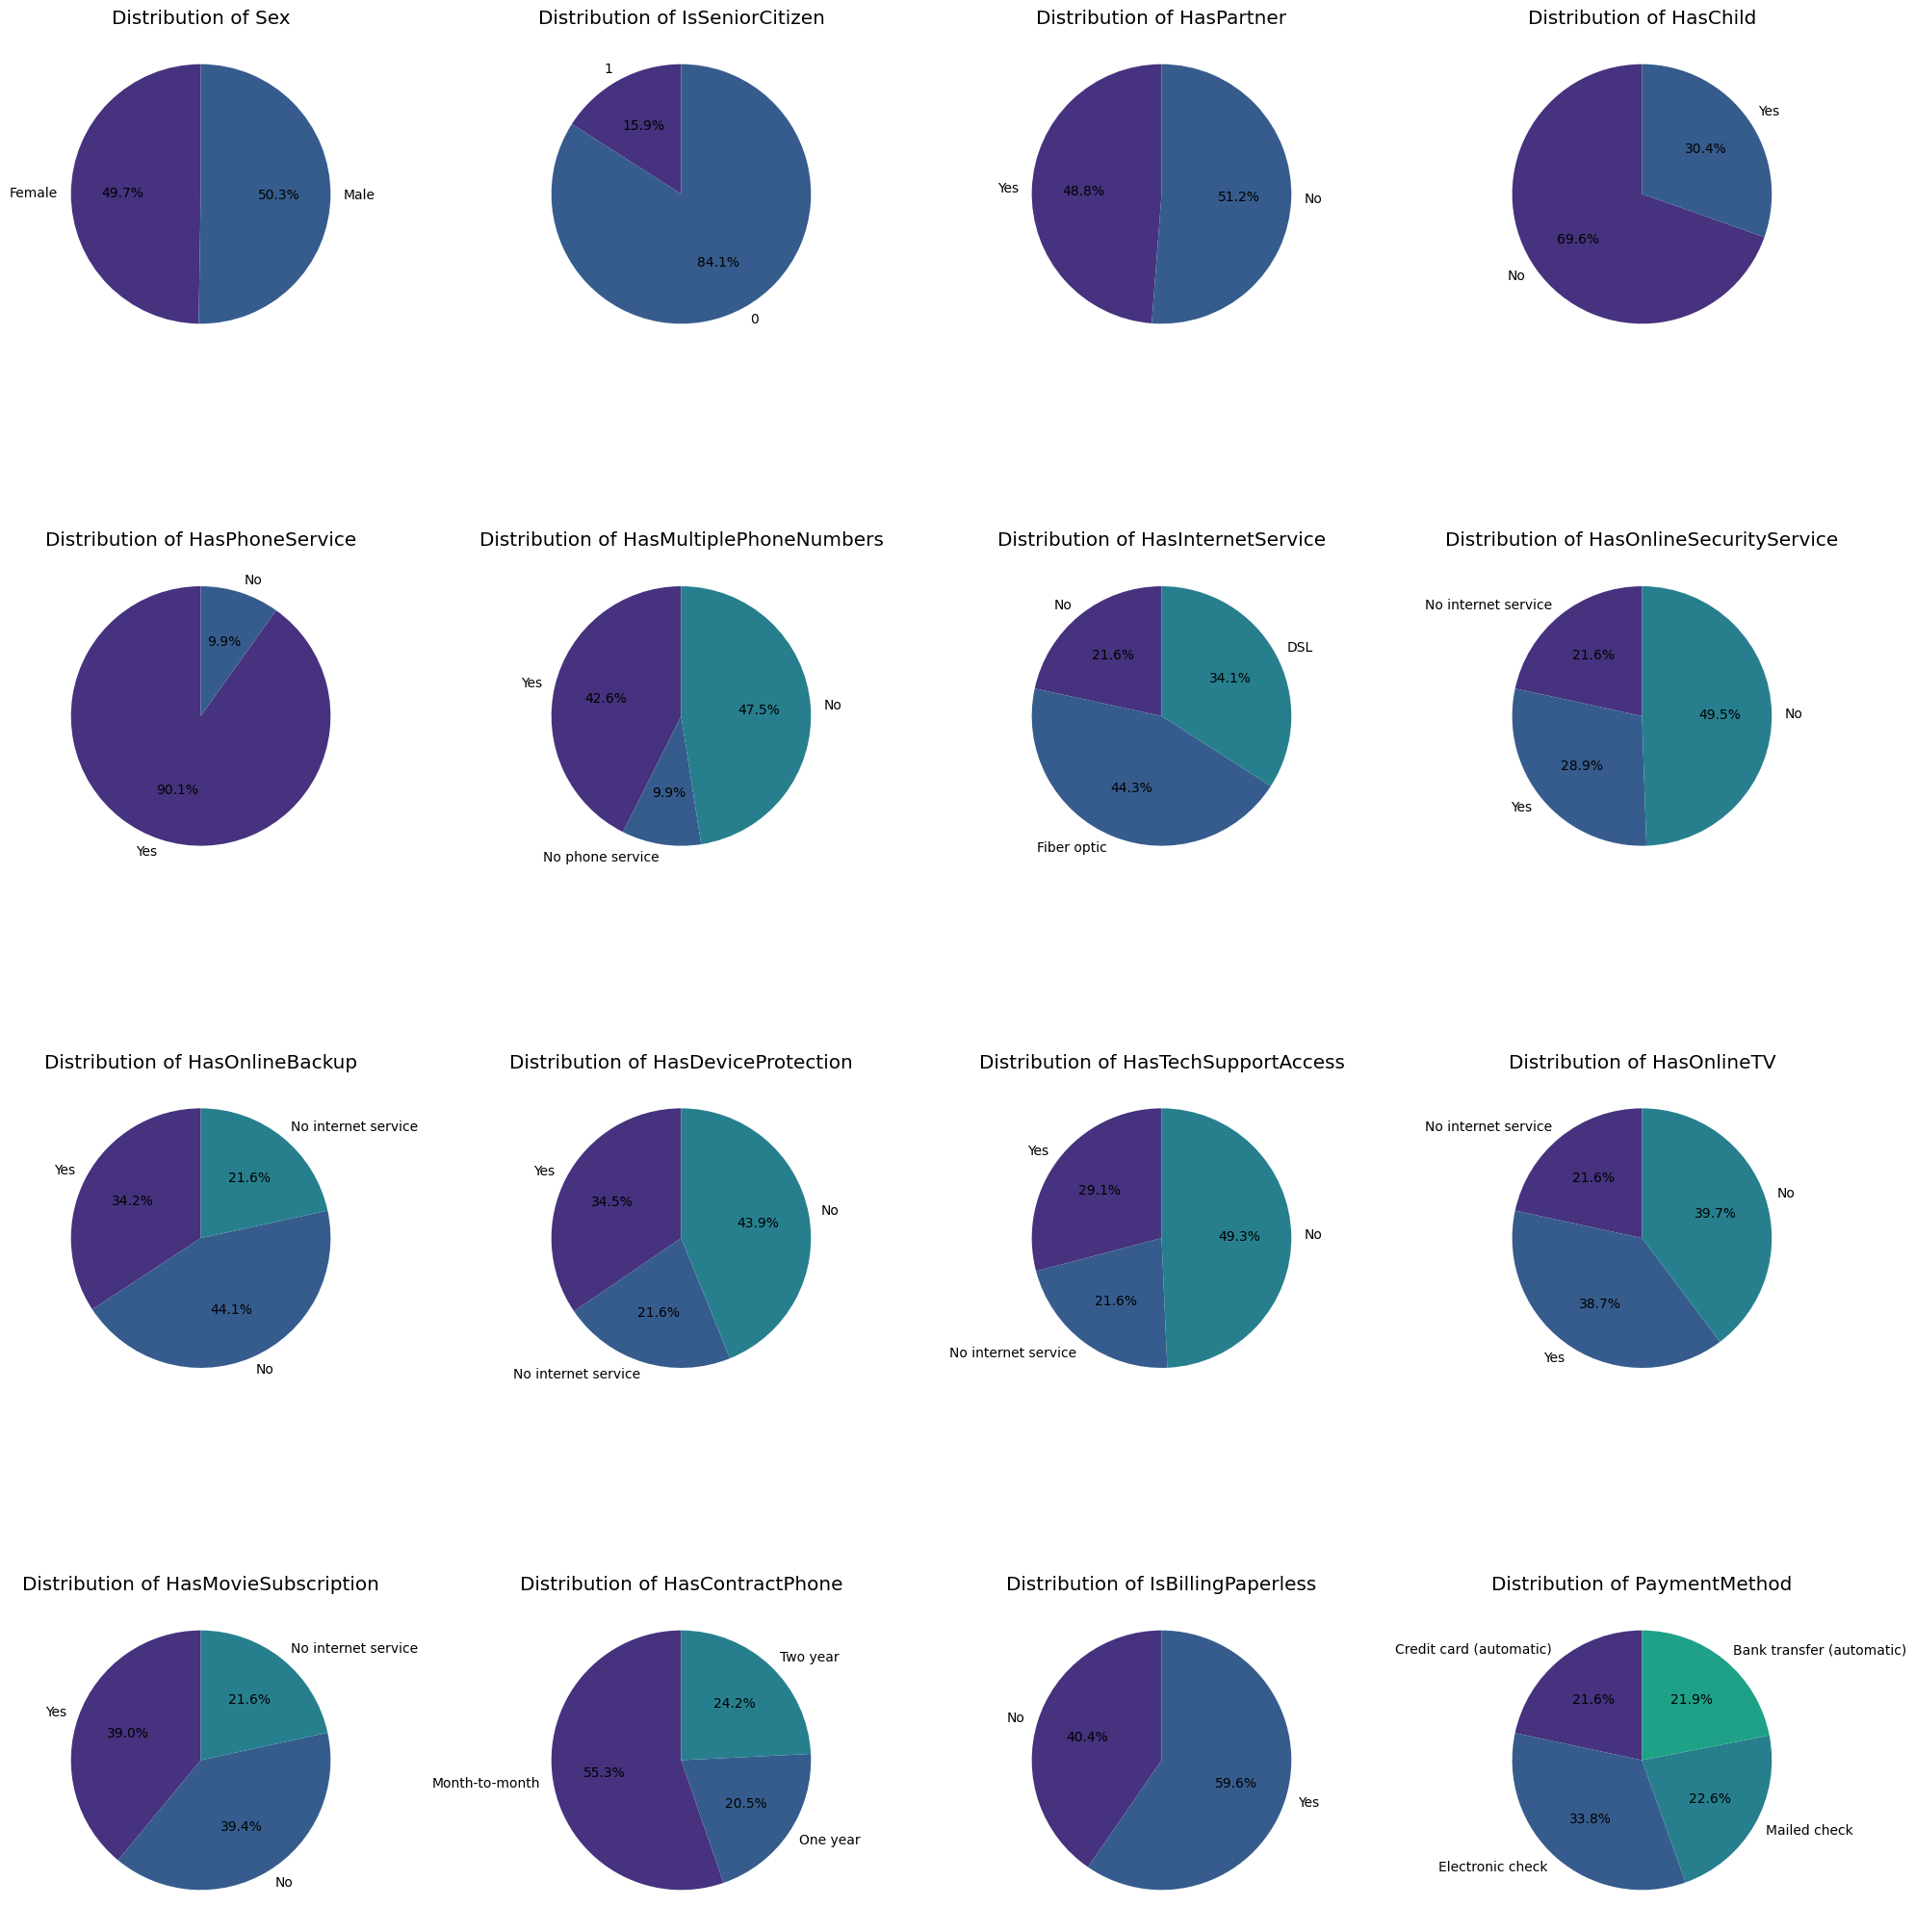

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure with a grid layout
rows = 4
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(20, 22))
axes = axes.flatten()  # Flatten to make indexing easier

# For each categorical column, create a bar chart
for i, col in enumerate(cat_cols):
    if i < len(axes):
        # Get value counts using group_by instead of value_counts + unnest
        # This is more reliable and provides consistent column names
        grouped = data.group_by(col).agg(pl.len().alias("count"))
        
        # Create bar chart on the corresponding subplot
        ax = axes[i]
        bars = ax.bar(grouped[col].to_list(), grouped["count"].to_list())
        
        # Add title and labels
        ax.set_title(f'Distribution of {col}')
        ax.set_ylabel('Count')
        
        # Rotate x-axis labels for better readability
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Add counts as text above bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=8)

# Handle any remaining empty subplots
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Create pie charts for categorical variables
plt.figure(figsize=(20, 22))
fig, axes = plt.subplots(rows, cols, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if i < len(axes):
        grouped = data.group_by(col).agg(pl.count().alias("count"))
        
        ax = axes[i]
        ax.pie(grouped["count"].to_list(), 
               labels=grouped[col].to_list(),
               autopct='%1.1f%%',
               startangle=90)
        
        ax.set_title(f'Distribution of {col}')

# Remove empty subplots
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])
    
plt.tight_layout()
plt.show()

In [23]:
data.sample(5)

ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
i64,f64,f64,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64
71,23.90,"1,626.40","""Male""",0,"""Yes""","""Yes""","""Yes""","""Yes""","""No""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""Two year""","""No""","""Credit card (automatic)""",0
1,99.75,99.75,"""Male""",0,"""No""","""Yes""","""Yes""","""Yes""","""Fiber optic""","""No""","""No""","""Yes""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",1
43,60.40,"2,640.55","""Female""",0,"""Yes""","""Yes""","""No""","""No phone service""","""DSL""","""Yes""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""One year""","""Yes""","""Credit card (automatic)""",0
3,55.90,157.55,"""Male""",0,"""No""","""Yes""","""Yes""","""No""","""DSL""","""Yes""","""No""","""Yes""","""No""","""No""","""No""","""Month-to-month""","""No""","""Mailed check""",0
43,55.55,"2,342.20","""Female""",1,"""Yes""","""No""","""No""","""No phone service""","""DSL""","""No""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""Month-to-month""","""No""","""Credit card (automatic)""",1


(Дополнительно) Если вы нашли какие-то ошибки в данных или выбросы, то можете их убрать. Тут можно поэксперементировать с обработкой данных как угодно, но не за баллы.

In [24]:
# YOUR CODE

## Применение линейных моделей (3 балла)

1) Обработайте данные для того, чтобы к ним можно было применить LogisticRegression. Т.е. отнормируйте числовые признаки, а категориальные закодируйте с помощью one-hot-encoding'а.

2) С помощью кроссвалидации или разделения на train/valid выборку протестируйте разные значения гиперпараметра C и выберите лучший (можно тестировать С=100, 10, 1, 0.1, 0.01, 0.001) по метрике ROC-AUC.

Если вы разделяете на train/valid, то используйте LogisticRegressionCV. Он сам при вызове .fit() подберет параметр С. (не забудьте передать scroing='roc_auc', чтобы при кроссвалидации сравнивались значения этой метрики, и refit=True, чтобы при потом модель обучилась на всем датасете с лучшим параметром C).


(более сложный вариант) Если вы будете использовать кроссвалидацию, то преобразования данных и LogisticRegression нужно соединить в один Pipeline с помощью make_pipeline, как это делалось во втором семинаре. Потом pipeline надо передать в GridSearchCV. Для one-hot-encoding'a можно испльзовать комбинацию LabelEncoder + OneHotEncoder (сначала превращаем строчки в числа, а потом числа првращаем в one-hot вектора.)

In [25]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline

In [26]:
# Для вашего удобства списки с именами разных колонок

# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [27]:
standardized_data = data.clone()
for col in num_cols:
    standardized_data = standardized_data.with_columns(
        ((pl.col(col) - pl.col(col).mean()) / pl.col(col).std()).alias(f"{col}_standardized")
    )

In [28]:

columns_to_keep = ['ClientPeriod_standardized', 'MonthlySpending_standardized', 'TotalSpent_standardized']
standardized_data = standardized_data.select(columns_to_keep)

In [29]:
standardized_data.sample(5)

ClientPeriod_standardized,MonthlySpending_standardized,TotalSpent_standardized
f64,f64,f64
1.37,-1.50,-0.46
-0.99,-1.51,-0.94
0.88,0.71,0.98
0.51,0.74,0.73
-1.28,-1.52,-1.00


In [30]:
cat_codes = data.select(cat_cols).to_dummies()

In [31]:
cat_codes.sample(5)

Sex_Female,Sex_Male,IsSeniorCitizen_0,IsSeniorCitizen_1,HasPartner_No,HasPartner_Yes,HasChild_No,HasChild_Yes,HasPhoneService_No,HasPhoneService_Yes,HasMultiplePhoneNumbers_No,HasMultiplePhoneNumbers_No phone service,HasMultiplePhoneNumbers_Yes,HasInternetService_DSL,HasInternetService_Fiber optic,HasInternetService_No,HasOnlineSecurityService_No,HasOnlineSecurityService_No internet service,HasOnlineSecurityService_Yes,HasOnlineBackup_No,HasOnlineBackup_No internet service,HasOnlineBackup_Yes,HasDeviceProtection_No,HasDeviceProtection_No internet service,HasDeviceProtection_Yes,HasTechSupportAccess_No,HasTechSupportAccess_No internet service,HasTechSupportAccess_Yes,HasOnlineTV_No,HasOnlineTV_No internet service,HasOnlineTV_Yes,HasMovieSubscription_No,HasMovieSubscription_No internet service,HasMovieSubscription_Yes,HasContractPhone_Month-to-month,HasContractPhone_One year,HasContractPhone_Two year,IsBillingPaperless_No,IsBillingPaperless_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
0,1,1,0,0,1,1,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,1,0,0,0,1,0
1,0,1,0,0,1,1,0,0,1,0,0,1,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0
1,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
1,0,0,1,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0
0,1,0,1,0,1,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,1,1,0,0,0


In [32]:
combined_features = cat_codes.hstack(standardized_data)

In [33]:
combined_features.sample(10)

Sex_Female,Sex_Male,IsSeniorCitizen_0,IsSeniorCitizen_1,HasPartner_No,HasPartner_Yes,HasChild_No,HasChild_Yes,HasPhoneService_No,HasPhoneService_Yes,HasMultiplePhoneNumbers_No,HasMultiplePhoneNumbers_No phone service,HasMultiplePhoneNumbers_Yes,HasInternetService_DSL,HasInternetService_Fiber optic,HasInternetService_No,HasOnlineSecurityService_No,HasOnlineSecurityService_No internet service,HasOnlineSecurityService_Yes,HasOnlineBackup_No,HasOnlineBackup_No internet service,HasOnlineBackup_Yes,HasDeviceProtection_No,HasDeviceProtection_No internet service,HasDeviceProtection_Yes,HasTechSupportAccess_No,HasTechSupportAccess_No internet service,HasTechSupportAccess_Yes,HasOnlineTV_No,HasOnlineTV_No internet service,HasOnlineTV_Yes,HasMovieSubscription_No,HasMovieSubscription_No internet service,HasMovieSubscription_Yes,HasContractPhone_Month-to-month,HasContractPhone_One year,HasContractPhone_Two year,IsBillingPaperless_No,IsBillingPaperless_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ClientPeriod_standardized,MonthlySpending_standardized,TotalSpent_standardized
u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,f64,f64,f64
0,1,1,0,0,1,1,0,0,1,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,1,1,0,0,0,1.53,1.12,2.01
1,0,1,0,0,1,0,1,0,1,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0.07,-0.14,-0.11
1,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,-1.08,-0.46,-0.88
1,0,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,1,0,-0.95,0.48,-0.69
0,1,1,0,1,0,1,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,0,1,0,-0.99,0.06,-0.78
1,0,1,0,0,1,0,1,0,1,1,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,0,1,1,0,0,0,0.80,0.63,0.90
0,1,0,1,0,1,0,1,0,1,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,1,0,0,1,0,0.11,0.37,0.20
0,1,1,0,1,0,1,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,-1.12,-0.59,-0.91
0,1,1,0,0,1,1,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,0,1,0,-1.28,0.66,-0.97


In [34]:
target_col

'Churn'

In [35]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

# Convert Polars DataFrame to numpy arrays for sklearn
X = combined_features.to_pandas().values
y = data["Churn"].to_pandas().values


In [36]:

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define C values to test
C_values = [100, 10, 1, 0.1, 0.01, 0.001]

# Create and train LogisticRegressionCV
lr_cv = LogisticRegressionCV(
    Cs=C_values,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',
    max_iter=1000,
    random_state=42,
    refit=True
)

# Fit the model
lr_cv.fit(X_train, y_train)


LogisticRegressionCV(Cs=[100, 10, 1, 0.1, 0.01, 0.001], cv=5, max_iter=1000,
                     random_state=42, scoring='roc_auc')

In [37]:
print(f"Best C value: {lr_cv.C_[0]}")


Best C value: 1.0


ROC-AUC on test set: 0.8545
C=100: mean ROC-AUC=0.8412
C=10: mean ROC-AUC=0.8412
C=1: mean ROC-AUC=0.8414
C=0.1: mean ROC-AUC=0.8408
C=0.01: mean ROC-AUC=0.8387
C=0.001: mean ROC-AUC=0.8347


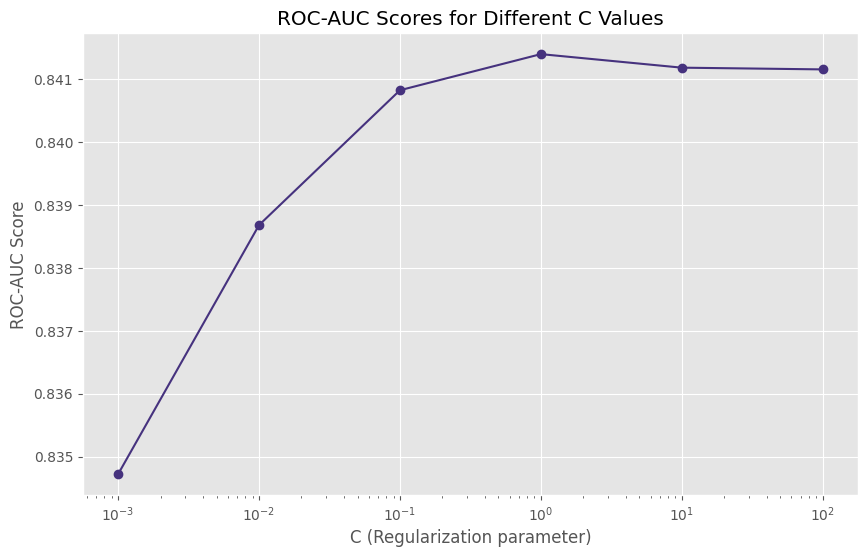

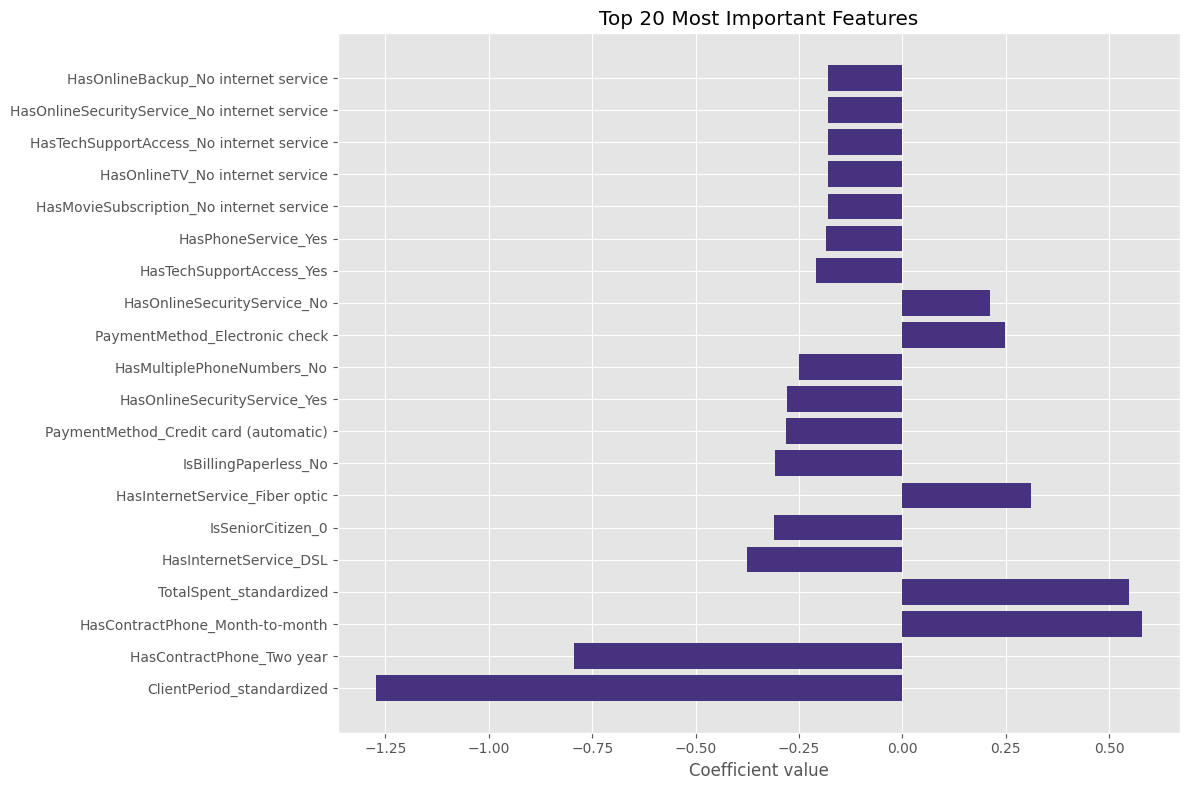

In [38]:

# Make predictions on test set
y_pred_proba = lr_cv.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC on test set: {roc_auc:.4f}")

# Print scores for each C value
mean_scores = lr_cv.scores_[1].mean(axis=0)
for C, score in zip(C_values, mean_scores):
    print(f"C={C}: mean ROC-AUC={score:.4f}")

# Visualize ROC-AUC scores for different C values
plt.figure(figsize=(10, 6))
plt.semilogx(C_values, mean_scores, marker='o')
plt.xlabel('C (Regularization parameter)')
plt.ylabel('ROC-AUC Score')
plt.title('ROC-AUC Scores for Different C Values')
plt.grid(True)
plt.show()

# Get feature importance
feature_names = combined_features.columns
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_cv.coef_[0]
})
coefficients = coefficients.sort_values('Coefficient', key=abs, ascending=False)

# Plot top 20 most important features
plt.figure(figsize=(12, 8))
plt.barh(range(20), coefficients['Coefficient'].head(20))
plt.yticks(range(20), coefficients['Feature'].head(20))
plt.xlabel('Coefficient value')
plt.title('Top 20 Most Important Features')
plt.tight_layout()
plt.show()

Выпишите какое лучшее качество и с какими параметрами вам удалось получить

## Применение градиентного бустинга (2 балла)

Если вы хотите получить баллы за точный ответ, то стоит попробовать градиентный бустинг. Часто градиентный бустинг с параметрами по умолчанию даст вам 80% результата за 0% усилий.

Мы будем использовать catboost, поэтому нам не надо кодировать категориальные признаки. Catboost сделает это сам (в .fit() надо передать cat_features=cat_cols). А численные признаки нормировать для моделей, основанных на деревьях не нужно.

1) Разделите выборку на train/valid. Протестируйте catboost cо стандартными параметрами.

2) Протестируйте разные занчения параметров количества деревьев и learning_rate'а и выберите лучшую по метрике ROC-AUC комбинацию.

(Дополнительно) Есть некоторые сложности с тем, чтобы использовать CatBoostClassifier вместе с GridSearchCV, поэтому мы не просим использовать кроссвалидацию. Но можете попробовать)

In [39]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np


In [40]:
data.sample(5)

ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
i64,f64,f64,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64
42,19.80,849.90,"""Male""",0,"""No""","""No""","""Yes""","""No""","""No""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""One year""","""No""","""Bank transfer (automatic)""",0
14,100.20,"1,369.80","""Female""",1,"""Yes""","""No""","""Yes""","""Yes""","""Fiber optic""","""No""","""Yes""","""No""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",1
68,76.90,"5,023.00","""Male""",0,"""No""","""No""","""Yes""","""Yes""","""DSL""","""Yes""","""Yes""","""Yes""","""No""","""No""","""Yes""","""One year""","""Yes""","""Credit card (automatic)""",0
1,69.10,69.10,"""Male""",1,"""No""","""No""","""Yes""","""No""","""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""No""","""Electronic check""",1
52,64.30,"3,410.60","""Female""",0,"""Yes""","""No""","""Yes""","""No""","""DSL""","""Yes""","""No""","""Yes""","""No""","""Yes""","""No""","""One year""","""Yes""","""Mailed check""",0


In [41]:

X = data.drop("Churn").to_pandas()
y = data.select(pl.col("Churn")).to_pandas()
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [42]:

# Identify categorical columns
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]


In [43]:

# Create Pool objects for CatBoost
train_pool = Pool(X_train, y_train, cat_features=cat_cols)
val_pool = Pool(X_val, y_val, cat_features=cat_cols)

# Initial model with default parameters
default_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    random_seed=42,
    eval_metric='AUC',
    verbose=100
)


In [44]:

# Fit the model
default_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)

# Get best validation score
best_score = default_model.get_best_score()
print(f"Best ROC-AUC with default parameters: {best_score['validation']['AUC']:.4f}")


0:	test: 0.8275572	best: 0.8275572 (0)	total: 51.7ms	remaining: 25.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8541122836
bestIteration = 43

Shrink model to first 44 iterations.
Best ROC-AUC with default parameters: 0.8541
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8541122836
bestIteration = 43

Shrink model to first 44 iterations.
Best ROC-AUC with default parameters: 0.8541


In [45]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
from optuna.visualization import plot_optimization_history, plot_param_importances


def objective(trial):
    
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.1, 10.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
        'bootstrap_type': trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS']),
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': 0  # Suppress output during optimization
    }
    # Handle conditional parameters
    if params['bootstrap_type'] == 'Bayesian':
        params['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0, 10.0)
    elif params['bootstrap_type'] == 'subsample':
        params['subsample'] = trial.suggest_float('subsample', 0.1, 1.0)
    
    # Create and train model
    model = CatBoostClassifier(**params)
    
    # Use early stopping to prevent overfitting
    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=50,
        verbose=False
    )
    
    # Return validation AUC score
    y_pred_proba = model.predict_proba(val_pool)[:, 1]
    auc_score = roc_auc_score(y_val, y_pred_proba)
    
    return auc_score  # Optuna tries to maximize this value


In [46]:

# Create an Optuna study
study = optuna.create_study(direction='maximize')

# Run optimization
n_trials = 100  # Adjust based on your computational resources
study.optimize(objective, n_trials=n_trials)

# Print optimization results
print("Best trial:")
trial = study.best_trial

print(f"  ROC-AUC: {trial.value:.4f}")
print("  Best hyperparameters:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-03-06 19:39:44,336] A new study created in memory with name: no-name-e24a2536-1fdd-437a-a27c-08577ea64256
[I 2025-03-06 19:39:44,769] Trial 0 finished with value: 0.8513769323336109 and parameters: {'iterations': 569, 'learning_rate': 0.19421496571269936, 'depth': 7, 'l2_leaf_reg': 0.16892229583519605, 'random_strength': 9.083339632780632, 'border_count': 84, 'grow_policy': 'SymmetricTree', 'bootstrap_type': 'Bernoulli'}. Best is trial 0 with value: 0.8513769323336109.
[I 2025-03-06 19:39:44,769] Trial 0 finished with value: 0.8513769323336109 and parameters: {'iterations': 569, 'learning_rate': 0.19421496571269936, 'depth': 7, 'l2_leaf_reg': 0.16892229583519605, 'random_strength': 9.083339632780632, 'border_count': 84, 'grow_policy': 'SymmetricTree', 'bootstrap_type': 'Bernoulli'}. Best is trial 0 with value: 0.8513769323336109.
[I 2025-03-06 19:39:44,995] Trial 1 finished with value: 0.8501504211793021 and parameters: {'iterations': 697, 'learning_rate': 0.2547993707023414, '

Best trial:
  ROC-AUC: 0.8618
  Best hyperparameters:
    iterations: 749
    learning_rate: 0.20236873387448617
    depth: 8
    l2_leaf_reg: 1.9796306607983272
    random_strength: 7.236533428942755
    border_count: 72
    grow_policy: Lossguide
    bootstrap_type: MVS


In [47]:

# Train final model with best parameters
best_params = study.best_params
best_params['eval_metric'] = 'AUC'  # Add back the fixed parameters
best_params['random_seed'] = 42
best_params['verbose'] = 100

# Create and train the final model
final_model = CatBoostClassifier(**best_params)
final_model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50
)


0:	test: 0.7410233	best: 0.7410233 (0)	total: 5.95ms	remaining: 4.45s
100:	test: 0.8572434	best: 0.8617814 (66)	total: 365ms	remaining: 2.34s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8617814496
bestIteration = 66

Shrink model to first 67 iterations.
100:	test: 0.8572434	best: 0.8617814 (66)	total: 365ms	remaining: 2.34s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8617814496
bestIteration = 66

Shrink model to first 67 iterations.


In [48]:

# Evaluate the final model
y_pred_proba = final_model.predict_proba(val_pool)[:, 1]
final_auc = roc_auc_score(y_val, y_pred_proba)
print(f"Final model ROC-AUC: {final_auc:.4f}")


Final model ROC-AUC: 0.8618


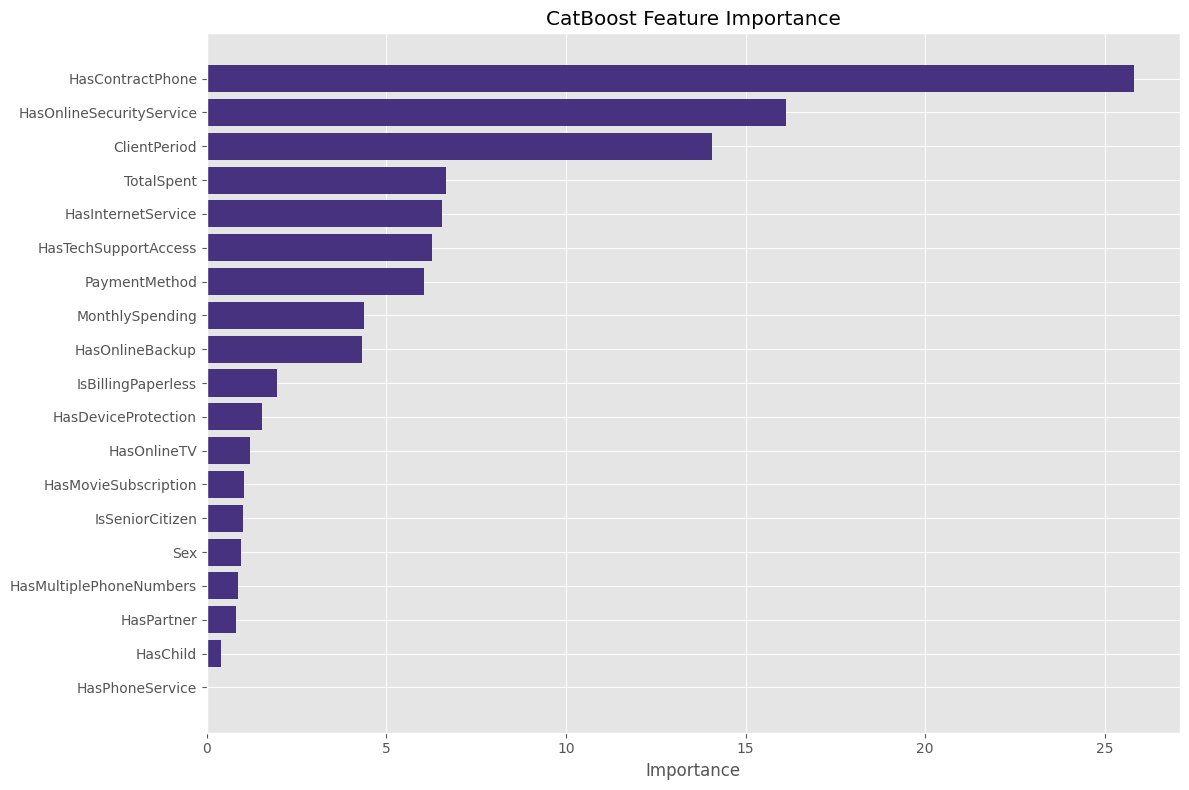

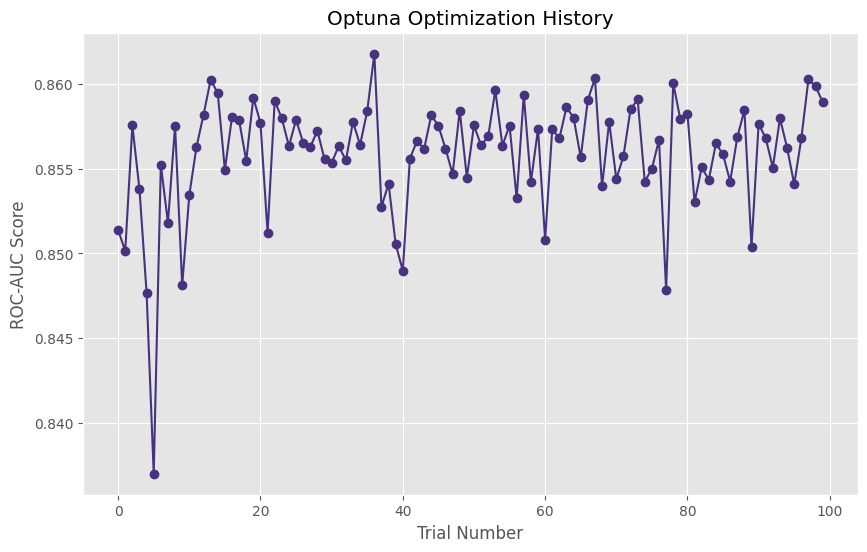

In [49]:

# Visualize feature importances
import matplotlib.pyplot as plt

feature_importance = final_model.get_feature_importance(train_pool)
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(train_pool.get_feature_names())[sorted_idx])
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Visualize the optimization history
plt.figure(figsize=(10, 6))
plt.plot(range(len(study.trials)), [t.value for t in study.trials], marker='o')
plt.xlabel('Trial Number')
plt.ylabel('ROC-AUC Score')
plt.title('Optuna Optimization History')
plt.grid(True)
plt.show()

# You can also visualize parameter importances
optuna.visualization.plot_param_importances(study)
plt.show()

Выпишите, какое лучшее качество и с какими параметрами вам удалось получить

ВАШ ОТВЕТ

# Предсказания

In [51]:
final_model

In [52]:
best_model = final_model

In [53]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')


In [54]:
test_pool = Pool(
    data=X_test,
    cat_features=cat_cols  
)

In [55]:
submission['Churn'] = best_model.predict_proba(test_pool)[:, 1]

submission.to_csv('./my_submission.csv', index=False)

Лучшее решение отправьте в Stepik.